# Cohort and Early Attrition Visualization

This notebook visualizes the cohort and early attrition outputs generated from the SQL analysis.

The goal is to understand when employee attrition happens, especially within the first 6 and 12 months after start date, and how early attrition varies across departments, employee types, performance scores, engagement segments and recruitment statuses.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

outputs_path = Path("/Users/joana/employee-lifecycle-analytics-sql/outputs")

attrition_by_start_year = pd.read_csv(outputs_path / "attrition_by_start_year.csv")
attrition_by_start_month = pd.read_csv(outputs_path / "attrition_by_start_month.csv")
early_attrition_overall = pd.read_csv(outputs_path / "early_attrition_overall.csv")
early_attrition_by_department = pd.read_csv(outputs_path / "early_attrition_by_department.csv")
early_attrition_by_employee_type = pd.read_csv(outputs_path / "early_attrition_by_employee_type.csv")
early_attrition_by_performance_score = pd.read_csv(outputs_path / "early_attrition_by_performance_score.csv")
early_attrition_by_engagement_segment = pd.read_csv(outputs_path / "early_attrition_by_engagement_segment.csv")
early_attrition_by_recruitment_status = pd.read_csv(outputs_path / "early_attrition_by_recruitment_status.csv")

print("Files loaded successfully.")

Files loaded successfully.


In [8]:
print("Attrition by start year:")
print(attrition_by_start_year.head())

print("\nEarly attrition overall:")
print(early_attrition_overall.head())

print("\nEarly attrition by department:")
print(early_attrition_by_department.head())

Attrition by start year:
   start_year  employees_started  terminated_employees  termination_rate_pct
0        2018                255                    40                 15.69
1        2019                598                    89                 14.88
2        2020                592                    70                 11.82
3        2021                600                    78                 13.00
4        2022                620                    79                 12.74

Early attrition overall:
   total_employees  terminated_employees  early_attrition_6m_employees  \
0             3000                   387                            96   

   early_attrition_6m_rate_pct  early_attrition_12m_employees  \
0                          3.2                            176   

   early_attrition_12m_rate_pct  pct_terminated_within_6m  \
0                          5.87                     24.81   

   pct_terminated_within_12m  
0                      45.48  

Early attrition by de

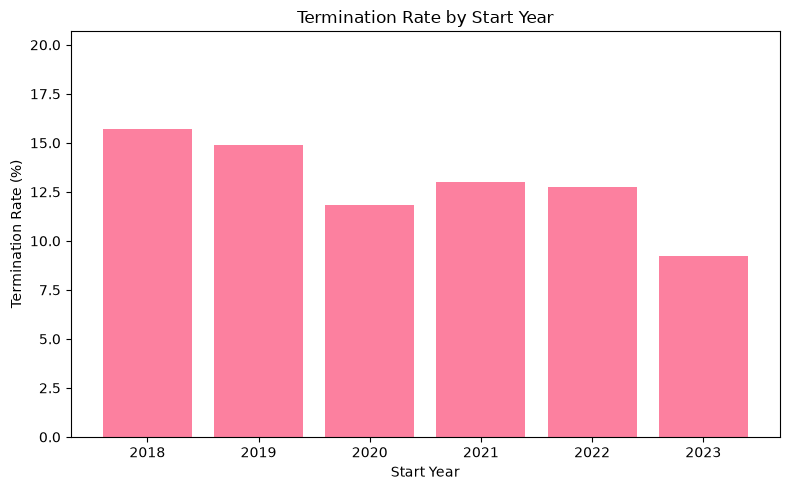

In [9]:
plt.figure(figsize=(8, 5))

plt.bar(
    attrition_by_start_year["start_year"].astype(str),
    attrition_by_start_year["termination_rate_pct"],
    color="#FC809F"
)

plt.title("Termination Rate by Start Year")
plt.xlabel("Start Year")
plt.ylabel("Termination Rate (%)")
plt.ylim(0, attrition_by_start_year["termination_rate_pct"].max() + 5)

plt.tight_layout()
plt.show()

Older cohorts show higher termination rates, but this should be interpreted carefully because these employees had more time to experience attrition. More recent cohorts, such as 2023, had a shorter exposure period.

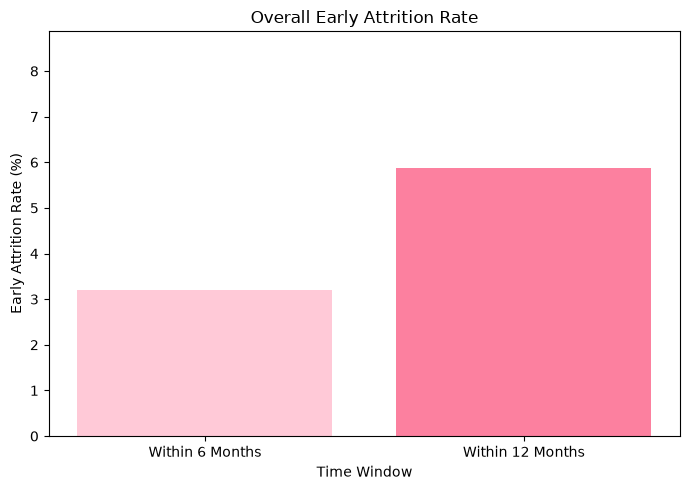

In [10]:
overall_metrics = pd.DataFrame({
    "Metric": ["Within 6 Months", "Within 12 Months"],
    "Rate": [
        early_attrition_overall.loc[0, "early_attrition_6m_rate_pct"],
        early_attrition_overall.loc[0, "early_attrition_12m_rate_pct"]
    ]
})

plt.figure(figsize=(7, 5))

plt.bar(
    overall_metrics["Metric"],
    overall_metrics["Rate"],
    color=["#FFC9D7", "#FC809F"]
)

plt.title("Overall Early Attrition Rate")
plt.xlabel("Time Window")
plt.ylabel("Early Attrition Rate (%)")
plt.ylim(0, overall_metrics["Rate"].max() + 3)

plt.tight_layout()
plt.show()

Although the 12-month early attrition rate represents 5.87% of the total workforce, it accounts for approximately 45.5% of all terminated employees. This suggests that the first year of employment is a critical period for retention.

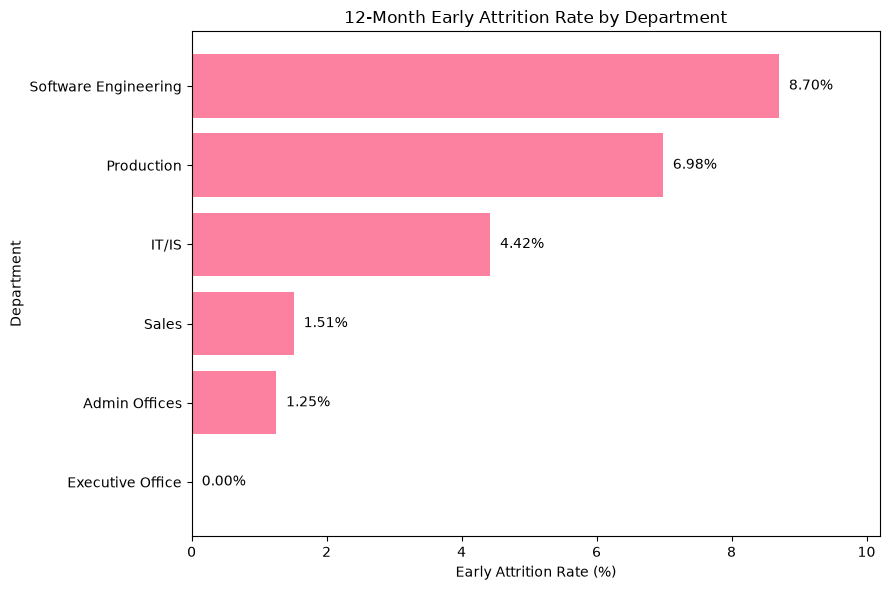

In [13]:
department_plot = early_attrition_by_department.sort_values(
    by="early_attrition_12m_rate_pct",
    ascending=True
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    department_plot["department_type"],
    department_plot["early_attrition_12m_rate_pct"],
    color="#FC809F"
)

plt.title("12-Month Early Attrition Rate by Department")
plt.xlabel("Early Attrition Rate (%)")
plt.ylabel("Department")

plt.xlim(0, department_plot["early_attrition_12m_rate_pct"].max() + 1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.15,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

Software Engineering had the highest 12-month early attrition rate, suggesting a higher proportional risk in this department. Production had the second-highest rate and, due to its large workforce size, also represents the highest absolute number of early attrition cases.

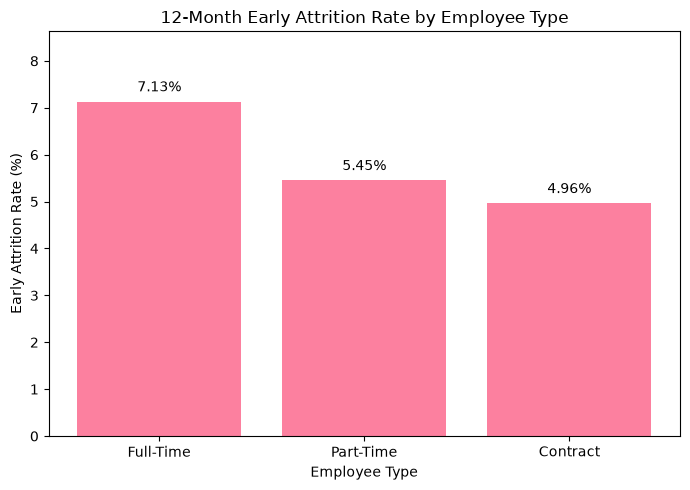

In [14]:
employee_type_plot = early_attrition_by_employee_type.sort_values(
    by="early_attrition_12m_rate_pct",
    ascending=False
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    employee_type_plot["employee_type"],
    employee_type_plot["early_attrition_12m_rate_pct"],
    color="#FC809F"
)

plt.title("12-Month Early Attrition Rate by Employee Type")
plt.xlabel("Employee Type")
plt.ylabel("Early Attrition Rate (%)")
plt.ylim(0, employee_type_plot["early_attrition_12m_rate_pct"].max() + 1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Full-Time employees showed the highest 12-month early attrition rate, followed by Part-Time and Contract employees. This suggests that early attrition is not necessarily concentrated among more flexible or temporary employment types in this dataset.

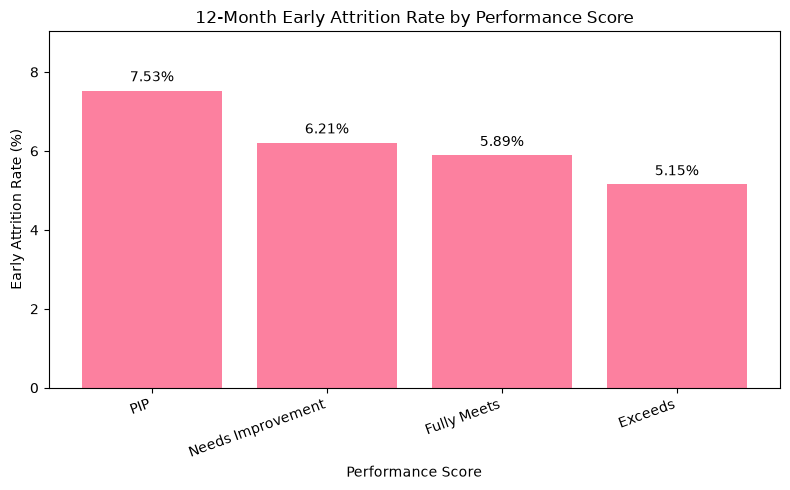

In [15]:
performance_plot = early_attrition_by_performance_score.sort_values(
    by="early_attrition_12m_rate_pct",
    ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    performance_plot["performance_score"],
    performance_plot["early_attrition_12m_rate_pct"],
    color="#FC809F"
)

plt.title("12-Month Early Attrition Rate by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Early Attrition Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, performance_plot["early_attrition_12m_rate_pct"].max() + 1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Employees in the PIP category had the highest 12-month early attrition rate, while employees rated as Exceeds had the lowest. This suggests that lower performance categories may be associated with higher early attrition, although the differences between groups are moderate.

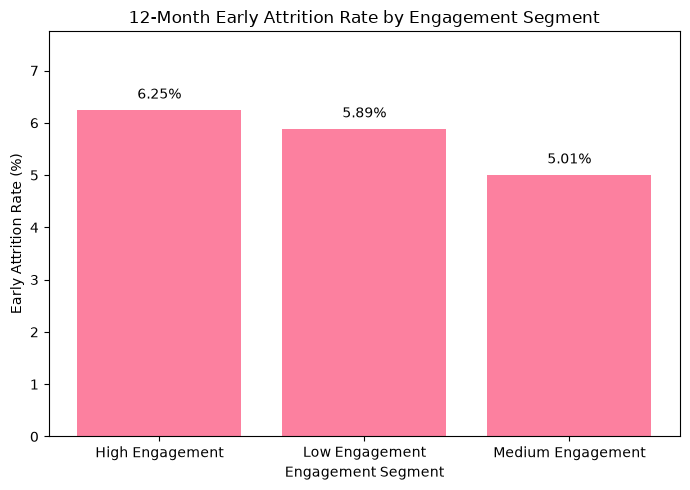

In [16]:
engagement_plot = early_attrition_by_engagement_segment.sort_values(
    by="early_attrition_12m_rate_pct",
    ascending=False
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    engagement_plot["engagement_segment"],
    engagement_plot["early_attrition_12m_rate_pct"],
    color="#FC809F"
)

plt.title("12-Month Early Attrition Rate by Engagement Segment")
plt.xlabel("Engagement Segment")
plt.ylabel("Early Attrition Rate (%)")
plt.ylim(0, engagement_plot["early_attrition_12m_rate_pct"].max() + 1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Engagement segment did not show a clear linear relationship with early attrition. High Engagement employees showed the highest 12-month early attrition rate, followed by Low and Medium Engagement employees. This reinforces the broader finding that engagement alone does not strongly explain attrition patterns in this dataset.

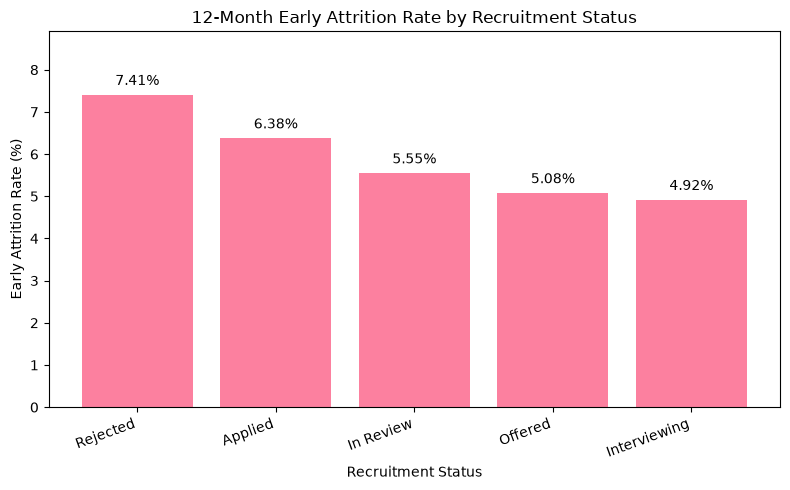

In [17]:
recruitment_plot = early_attrition_by_recruitment_status.sort_values(
    by="early_attrition_12m_rate_pct",
    ascending=False
)

plt.figure(figsize=(8, 5))

bars = plt.bar(
    recruitment_plot["recruitment_status"],
    recruitment_plot["early_attrition_12m_rate_pct"],
    color="#FC809F"
)

plt.title("12-Month Early Attrition Rate by Recruitment Status")
plt.xlabel("Recruitment Status")
plt.ylabel("Early Attrition Rate (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, recruitment_plot["early_attrition_12m_rate_pct"].max() + 1.5)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Recruitment status should be interpreted with caution. The Rejected group showed the highest 12-month early attrition rate, which would not be expected in a real recruitment-to-employee pipeline. This likely reflects the synthetic or simplified structure of the dataset and the assumption that `applicant_id` corresponds to `employee_id`.

## Conclusion

The cohort and early attrition analysis added a temporal perspective to the employee lifecycle project by examining when employees tend to leave after joining the organization.

The analysis showed that 96 employees left within the first 6 months, representing 3.20% of the total workforce. Within the first 12 months, 176 employees left, representing 5.87% of the workforce and approximately 45.5% of all terminated employees. This suggests that the first year of employment is a critical period for retention.

At department level, Software Engineering had the highest 12-month early attrition rate, while Production had the highest absolute number of early attrition cases due to its large workforce size. This indicates that Software Engineering may represent a higher proportional risk, while Production may represent a larger operational impact.

By employee type, Full-Time employees showed the highest 12-month early attrition rate. By performance score, employees in the PIP category had the highest early attrition rate, suggesting some relationship between lower performance and early employee exits.

Engagement segment did not show a clear linear relationship with early attrition. This reinforces a broader finding from the SQL and predictive modeling analysis: engagement alone does not strongly explain attrition patterns in this dataset.

Recruitment status results should be interpreted with caution because the dataset structure assumes that applicant IDs correspond to employee IDs, and some recruitment statuses may not reflect a realistic hiring pipeline.

Overall, this analysis shows how SQL-generated outputs can be reused in Python to create clear visualizations and communicate HR analytics insights more effectively.